In [403]:
import pandas as pd
import random

from pathlib import Path
from string import Template

In [404]:
OUTPUT_FILE            = Path('confounds/simulate_k.h5')
FORCE_OVERWRITE_OUTPUT = False
NUM_ROIS_TO_SAMPLE     = None # This can affect the MVMD output. Set to None to include all channels. Must be <= NUM_ROIS

# If left empty, random subjects are selected
SUBJECTS_TO_SAMPLE     = [
  'sub-NDARINVAG388HJL'
]
SUBJECT_SAMPLE_SIZE    = 1 if SUBJECTS_TO_SAMPLE == [] else len(SUBJECTS_TO_SAMPLE) # Clamped to max the number of available participants in FMRI_PREP_DIR

In [405]:
# What fMRI data will you run analysis on
FMRI_PREP_DIR  = Path("/Volumes/work/masters_thesis/Transdiagnostic/output/fmriprep-25.1.4") # Replace with /cluster/work/{username} on IDUN
FILE_SUFFIX    = "_task-restAP_run-01_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz" # Arbitrarily chosen Rest run

In [406]:
# Atlas volume files
CORTICAL_ATLAS     = Path("/Volumes/ianpe/masters-thesis/atlas/400Parcels_Yeo2011_17Networks_FSLMNI152_2mm.nii.gz")
SUBCORTICAL_ATLAS  = Path("/Volumes/ianpe/masters-thesis/atlas/Tian_Subcortex_S2_3T.nii")
NUM_ROIS           = 432

In [407]:
# Global HDF5 groups
PARCELLATION_GROUP_TEMPLATE  = "{subject_id}/parcellation"
MVMD_GROUP_TEMPLATE          = "{subject_id}/mvmd"
DECOMPOSITION_GROUP_TEMPLATE = "{subject_id}/mvmd/K_{k}"

In [408]:
random.seed(42) # Reproducibility

In [409]:
# fMRIPrep data
subject_ids = [d.name for d in FMRI_PREP_DIR.iterdir() if d.is_dir() and d.name.startswith("sub-NDARINV")]
subject_count = len(subject_ids)
print(f"Subject Directories [{subject_count}]:", subject_ids)

Subject Directories [2]: ['sub-NDARINVAL101MH2', 'sub-NDARINVAG388HJL']


In [410]:
# Remove available subjects if they are missing the required file
subjects_with_file = []
for sub_id in subject_ids:
  subject_func_dir = FMRI_PREP_DIR / sub_id / "func" / f"{sub_id}{FILE_SUFFIX}"
  if subject_func_dir.is_file():
    subjects_with_file.append(sub_id)

subject_with_file_count = len(subjects_with_file)

# Fetch specified subjects if applicable
filtered_subjects = subjects_with_file if SUBJECTS_TO_SAMPLE == [] else list(set(subjects_with_file).intersection(set(SUBJECTS_TO_SAMPLE)))
filtered_subjects_count = len(filtered_subjects)
    
print(f"Subjects with data [{subject_count}]:", subject_ids)
print(f"Subjects with specified file [{filtered_subjects_count}]:", filtered_subjects)

Subjects with data [2]: ['sub-NDARINVAL101MH2', 'sub-NDARINVAG388HJL']
Subjects with specified file [1]: ['sub-NDARINVAG388HJL']


In [411]:
# Select subjects

subject_sample_size = max(1, min(filtered_subjects_count, SUBJECT_SAMPLE_SIZE)) # Clamp to realistic sample sizes
sampled_subjects = random.sample(filtered_subjects, k=subject_sample_size)
print("Subjects to sample:", sampled_subjects)

Subjects to sample: ['sub-NDARINVAG388HJL']


In [412]:
# Prepare confounds output
import h5py
import numpy as np

if FORCE_OVERWRITE_OUTPUT:
  with h5py.File(OUTPUT_FILE, 'w') as f:
    pass

In [413]:
from nilearn.image import load_img
from nilearn.maskers import NiftiLabelsMasker

for sub_id in sampled_subjects:
  fmri_file = FMRI_PREP_DIR / sub_id / "func" / f"{sub_id}{FILE_SUFFIX}"
  bold_img = load_img(str(fmri_file))
  
  # Cortical Parcellation
  with h5py.File(OUTPUT_FILE, 'a') as f:
    parcellation_group = f.require_group(PARCELLATION_GROUP_TEMPLATE.format(subject_id=sub_id))
    
    # Cortical Parcellation
    cortical_parcellation_dataset = "cortical_parcellation"
    if cortical_parcellation_dataset not in parcellation_group:
      cortical_masker = NiftiLabelsMasker(
        labels_img=str(CORTICAL_ATLAS),
        standardize=False,
        detrend=False,
        resampling_target="data"
      )
      cortical_ts = cortical_masker.fit_transform(bold_img).T

      parcellation_group.create_dataset(cortical_parcellation_dataset, data=cortical_ts) # Dataset at the root level
      print("Extracted cortical parcellations")
    else:
      print("SKIPPING: Cortical parcellation already in file.")
  
    # Subcortical Parcellation
    subcortical_parcellation_dataset = "subcortical_parcellation"
    if subcortical_parcellation_dataset not in parcellation_group:
      subcortical_masker = NiftiLabelsMasker(
        labels_img=str(SUBCORTICAL_ATLAS),
        standardize=False,
        detrend=False,
        resampling_target="data"
      )
      subcortical_ts = subcortical_masker.fit_transform(bold_img).T
    
      parcellation_group.create_dataset(subcortical_parcellation_dataset, data=subcortical_ts)
      print("Extracted subcortical parcellations")
    else:
      print("SKIPPING: Subcortical parcellation already in file.")
      
    # Combined
    combined_parcellation_dataset = "cortical_subcortical_parcellation"
    if combined_parcellation_dataset not in parcellation_group:
      combined_ts = np.vstack([cortical_ts, subcortical_ts])
      parcellation_group.create_dataset(combined_parcellation_dataset, data=combined_ts)
      print("Extracted cortico-subcortical parcellations")
    else:
      print("SKIPPING: Cortico-subcortical parcellation already in file.")

Extracted cortical parcellations
Extracted subcortical parcellations
Extracted cortico-subcortical parcellations


In [414]:
num_rois_to_sample = NUM_ROIS_TO_SAMPLE if NUM_ROIS_TO_SAMPLE is not None else NUM_ROIS

roi_to_sample = sorted(random.sample(range(0, NUM_ROIS), k=num_rois_to_sample))
print("ROIs to sample:", roi_to_sample)

ROIs to sample: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218

In [415]:
# MVMD hyperparameters
from lib.mvmd.mvmd import mvmd
Ks = range(4, 15) # Should minimum have same number of modes as slow-bands (2, 3, 4, 5)(?)

In [416]:
# Run MVMD for all K's
for sub_id in sampled_subjects:
  h5_parcellation_path = PARCELLATION_GROUP_TEMPLATE.format(subject_id=sub_id)
  h5_mvmd_path         = MVMD_GROUP_TEMPLATE.format(subject_id=sub_id)

  # --- Determine which K values need (re)computation ---
  with h5py.File(OUTPUT_FILE, 'a') as f:
    mvmd_group = f.require_group(h5_mvmd_path)

    # Read stored metadata so we can compare against current hyperparameters
    stored_num_ch = int(mvmd_group.attrs["num_channels"]) if "num_channels" in mvmd_group.attrs else None
    stored_roi    = np.array(mvmd_group.attrs["roi_indices"]) if "roi_indices" in mvmd_group.attrs else None

    metadata_unchanged = (
      not FORCE_OVERWRITE_OUTPUT
      and stored_num_ch == num_rois_to_sample
      and stored_roi is not None
      and np.array_equal(stored_roi, np.array(roi_to_sample))
    )

    ks_to_compute = []
    for k in Ks:
      k_path = DECOMPOSITION_GROUP_TEMPLATE.format(subject_id=sub_id, k=k)
      if (metadata_unchanged
          and k_path in f
          and all(ds in f[k_path] for ds in ["modes", "modes_hat", "omega"])):
        continue  # fully cached, identical params
      ks_to_compute.append(k)

    # Always keep stored metadata current
    mvmd_group.attrs["num_channels"] = np.array(num_rois_to_sample)
    mvmd_group.attrs["roi_indices"]  = np.array(roi_to_sample)

  # Inform the user what changed and what will be skipped
  if not FORCE_OVERWRITE_OUTPUT and not metadata_unchanged and stored_num_ch is not None:
    print(
      f"WARNING {sub_id}: hyperparameters changed "
      f"(num_channels {stored_num_ch} → {num_rois_to_sample} or ROIs differ). "
      f"Recomputing all K values."
    )

  ks_skipped = [k for k in Ks if k not in ks_to_compute]
  if ks_skipped:
    print(f"{sub_id}: SKIPPING K={ks_skipped} — cached and hyperparameters unchanged.")

  if not ks_to_compute:
    print(f"{sub_id}: All K values already computed, nothing to do.")
    continue

  # --- Load time series only when there is work to do ---
  with h5py.File(OUTPUT_FILE, 'r') as f:
    all_ts = f[h5_parcellation_path]["cortical_subcortical_parcellation"][roi_to_sample][:]

  # --- Compute and store missing K values ---
  for k in ks_to_compute:
    k_path = DECOMPOSITION_GROUP_TEMPLATE.format(subject_id=sub_id, k=k)
    with h5py.File(OUTPUT_FILE, 'a') as f:
      k_group = f.require_group(k_path)
      modes, modes_hat, omega = mvmd(all_ts, num_modes=k, alpha=2000, tolerance=1e-3, sampling_rate=1)

      if "modes" in k_group:
        del k_group["modes"]
      k_group.create_dataset("modes", data=modes)

      if "modes_hat" in k_group:
        del k_group["modes_hat"]
      k_group.create_dataset("modes_hat", data=modes_hat)

      if "omega" in k_group:
        del k_group["omega"]
      k_group.create_dataset("omega", data=omega)

    print(f"{sub_id}: Computed K={k}.")

sub-NDARINVAG388HJL: Computed K=4.
sub-NDARINVAG388HJL: Computed K=5.
sub-NDARINVAG388HJL: Computed K=6.
sub-NDARINVAG388HJL: Computed K=7.
sub-NDARINVAG388HJL: Computed K=8.
sub-NDARINVAG388HJL: Computed K=9.
sub-NDARINVAG388HJL: Computed K=10.
sub-NDARINVAG388HJL: Computed K=11.
sub-NDARINVAG388HJL: Computed K=12.
sub-NDARINVAG388HJL: Computed K=13.
sub-NDARINVAG388HJL: Computed K=14.


In [417]:
def delete_group(group):
  with h5py.File(OUTPUT_FILE, 'a') as f:
    if group in f:
      del f[group]
      
# delete_group(f"{sub_id}/mvmd") # For resetting

In [418]:
def list_subgroups(group):
    """
    Lists the names of all direct subgroups within an h5py Group object.
    """
    subgroup_names = []
    for key in group.keys():
        item = group[key]
        # Check if the item is an instance of h5py.Group
        if isinstance(item, h5py.Group):
            subgroup_names.append(key)
    return subgroup_names

In [419]:
# Compute reconstruction quality metrics and store results in HDF5
from scipy import stats as scipy_stats

for sub_id in sampled_subjects:
  h5_parcellation_group = PARCELLATION_GROUP_TEMPLATE.format(subject_id=sub_id)
  h5_mvmd_group = MVMD_GROUP_TEMPLATE.format(subject_id=sub_id)

  with h5py.File(OUTPUT_FILE, 'a') as f:
    parcellation_group = f[h5_parcellation_group]
    mvmd_group = f[h5_mvmd_group]

    roi_indices = mvmd_group.attrs["roi_indices"]
    original = parcellation_group["cortical_subcortical_parcellation"][roi_indices][:]  # (C, N)
    num_channels, num_timepoints = original.shape

    decomposition_keys = sorted(list_subgroups(mvmd_group), key=lambda x: int(x.split("_")[-1]))

    print(f"Subject ({sub_id}) | Original signal shape: {original.shape}")
    header = f"{'K':>4} | {'SNR (dB)':>10} | {'NMSE':>12} | {'Pearson r':>10} | {'R²':>8} | {'RMSE':>8}"
    print(header)
    print("-" * len(header))

    for decomp_key in decomposition_keys:
      k = int(decomp_key.split("_")[-1])
      k_group = f[DECOMPOSITION_GROUP_TEMPLATE.format(subject_id=sub_id, k=k)]

      if "reconstruction" in k_group and not FORCE_OVERWRITE_OUTPUT:
        metrics_grp = k_group["metrics"]
        print(
          f"{k:>4} | {metrics_grp.attrs['mean_snr_db']:>10.4f} | "
          f"{metrics_grp.attrs['mean_nmse']:>12.8f} | "
          f"{metrics_grp.attrs['mean_pearson_r']:>10.6f} | "
          f"{metrics_grp.attrs['mean_r_squared']:>8.6f} | "
          f"{metrics_grp.attrs['mean_rmse']:>8.4f}  (cached)"
        )
        continue

      modes = k_group["modes"][:]          # (K, C, N)
      reconstruction = np.sum(modes, axis=0)  # (C, N) — sum all modes to recover original signal

      # --- Per-channel metrics (C,) each ---
      residual    = original - reconstruction
      signal_power = np.sum(original ** 2, axis=1)
      noise_power  = np.sum(residual ** 2, axis=1)

      mse_per_ch       = np.mean(residual ** 2, axis=1)
      rmse_per_ch      = np.sqrt(mse_per_ch)
      mae_per_ch       = np.mean(np.abs(residual), axis=1)
      nmse_per_ch      = noise_power / signal_power           # 0 = perfect reconstruction
      snr_db_per_ch    = 10 * np.log10(signal_power / noise_power)  # dB, higher = better

      # Pearson r: linear agreement between original and reconstruction
      pearson_r_per_ch = np.array([
        scipy_stats.pearsonr(original[c], reconstruction[c])[0]
        for c in range(num_channels)
      ])

      # R^2: proportion of variance in the original explained by the reconstruction
      ss_res = np.sum(residual ** 2, axis=1)
      ss_tot = np.sum((original - np.mean(original, axis=1, keepdims=True)) ** 2, axis=1)
      r_squared_per_ch = 1 - ss_res / ss_tot

      # --- Store reconstruction ---
      if "reconstruction" in k_group:
        del k_group["reconstruction"]
      k_group.create_dataset("reconstruction", data=reconstruction)

      # --- Store metrics group ---
      if "metrics" in k_group:
        del k_group["metrics"]
      metrics_grp = k_group.create_group("metrics")

      # Metadata
      metrics_grp.attrs["k"]              = k
      metrics_grp.attrs["num_channels"]   = num_channels
      metrics_grp.attrs["num_timepoints"] = num_timepoints
      metrics_grp.attrs["roi_indices"]    = roi_indices

      # Per-channel datasets — shape (C,) each
      metrics_grp.create_dataset("mse",       data=mse_per_ch)
      metrics_grp.create_dataset("rmse",      data=rmse_per_ch)
      metrics_grp.create_dataset("mae",       data=mae_per_ch)
      metrics_grp.create_dataset("nmse",      data=nmse_per_ch)
      metrics_grp.create_dataset("snr_db",    data=snr_db_per_ch)
      metrics_grp.create_dataset("pearson_r", data=pearson_r_per_ch)
      metrics_grp.create_dataset("r_squared", data=r_squared_per_ch)

      # Channel-mean scalar attrs for fast cross-K retrieval
      metrics_grp.attrs["mean_mse"]       = float(np.mean(mse_per_ch))
      metrics_grp.attrs["mean_rmse"]      = float(np.mean(rmse_per_ch))
      metrics_grp.attrs["mean_mae"]       = float(np.mean(mae_per_ch))
      metrics_grp.attrs["mean_nmse"]      = float(np.mean(nmse_per_ch))
      metrics_grp.attrs["mean_snr_db"]    = float(np.mean(snr_db_per_ch))
      metrics_grp.attrs["mean_pearson_r"] = float(np.mean(pearson_r_per_ch))
      metrics_grp.attrs["mean_r_squared"] = float(np.mean(r_squared_per_ch))

      print(
        f"{k:>4} | {np.mean(snr_db_per_ch):>10.4f} | "
        f"{np.mean(nmse_per_ch):>12.8f} | "
        f"{np.mean(pearson_r_per_ch):>10.6f} | "
        f"{np.mean(r_squared_per_ch):>8.6f} | "
        f"{np.mean(rmse_per_ch):>8.4f}"
      )

Subject (sub-NDARINVAG388HJL) | Original signal shape: (432, 488)
   K |   SNR (dB) |         NMSE |  Pearson r |       R² |     RMSE
-------------------------------------------------------------------
   4 |    52.3943 |   0.00000807 |   0.898231 | 0.801388 |  19.5601
   5 |    56.4547 |   0.00000354 |   0.956721 | 0.914653 |  12.2534
   6 |    56.2358 |   0.00000359 |   0.957875 | 0.913150 |  12.5381
   7 |    57.3596 |   0.00000273 |   0.967643 | 0.933124 |  11.0188
   8 |    58.6424 |   0.00000200 |   0.976514 | 0.950950 |   9.5158
   9 |    60.3355 |   0.00000135 |   0.984092 | 0.966845 |   7.8300
  10 |    62.0969 |   0.00000091 |   0.988930 | 0.977603 |   6.3893
  11 |    65.1192 |   0.00000045 |   0.994503 | 0.988909 |   4.5107
  12 |    65.5151 |   0.00000043 |   0.994797 | 0.989458 |   4.3160
  13 |    66.2165 |   0.00000036 |   0.995692 | 0.991227 |   3.9756
  14 |    66.9929 |   0.00000029 |   0.996507 | 0.992907 |   3.6360


Display K=[4, 9, 10, 14]  (best=14, worst=4, random fill=[9, 10])
Sampled channels: indices [20, 107, 183, 407]  (ROIs: [ 20 107 183 407])


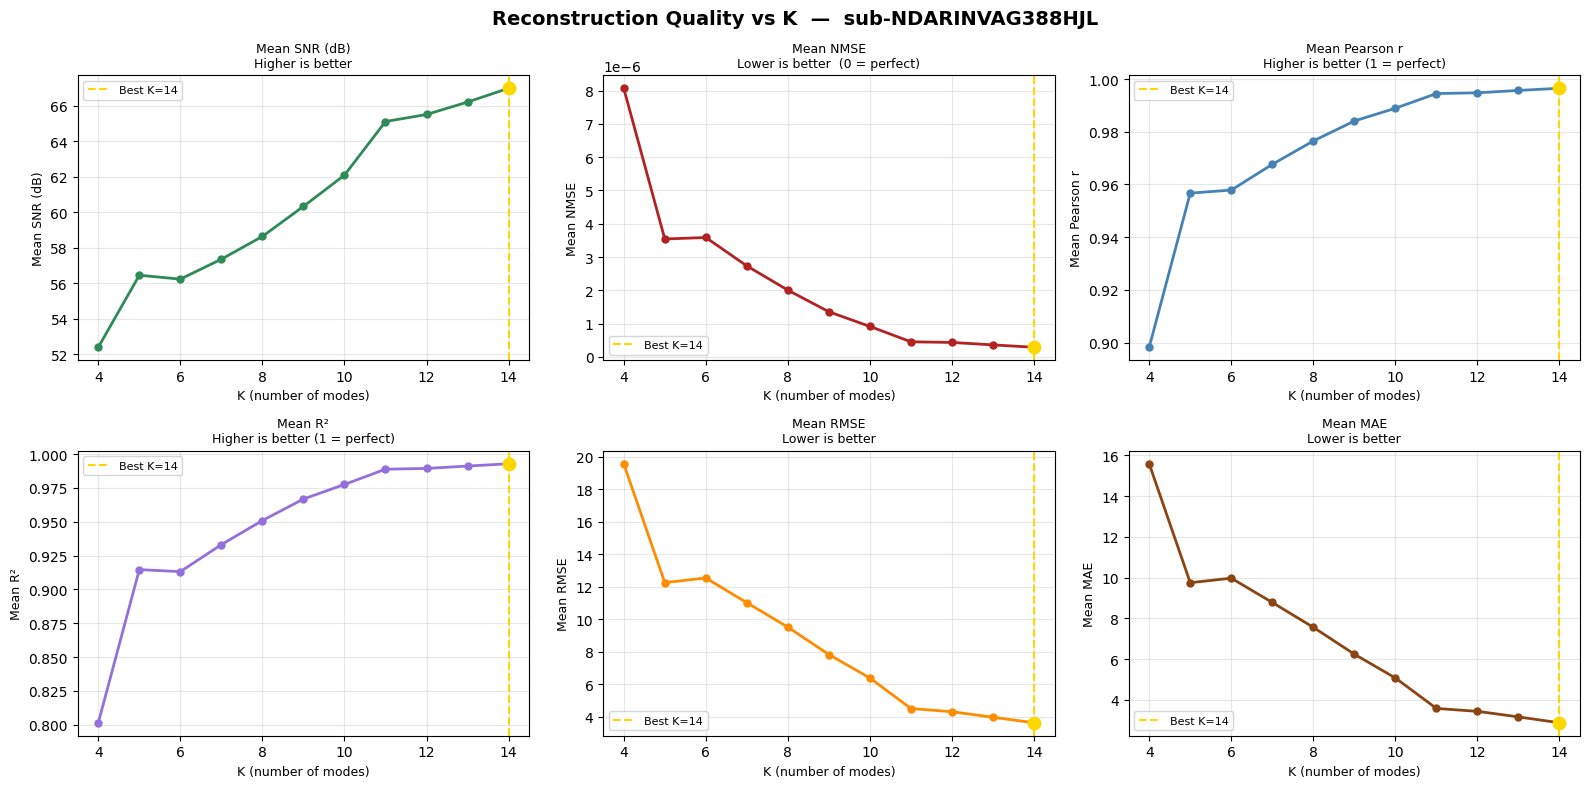

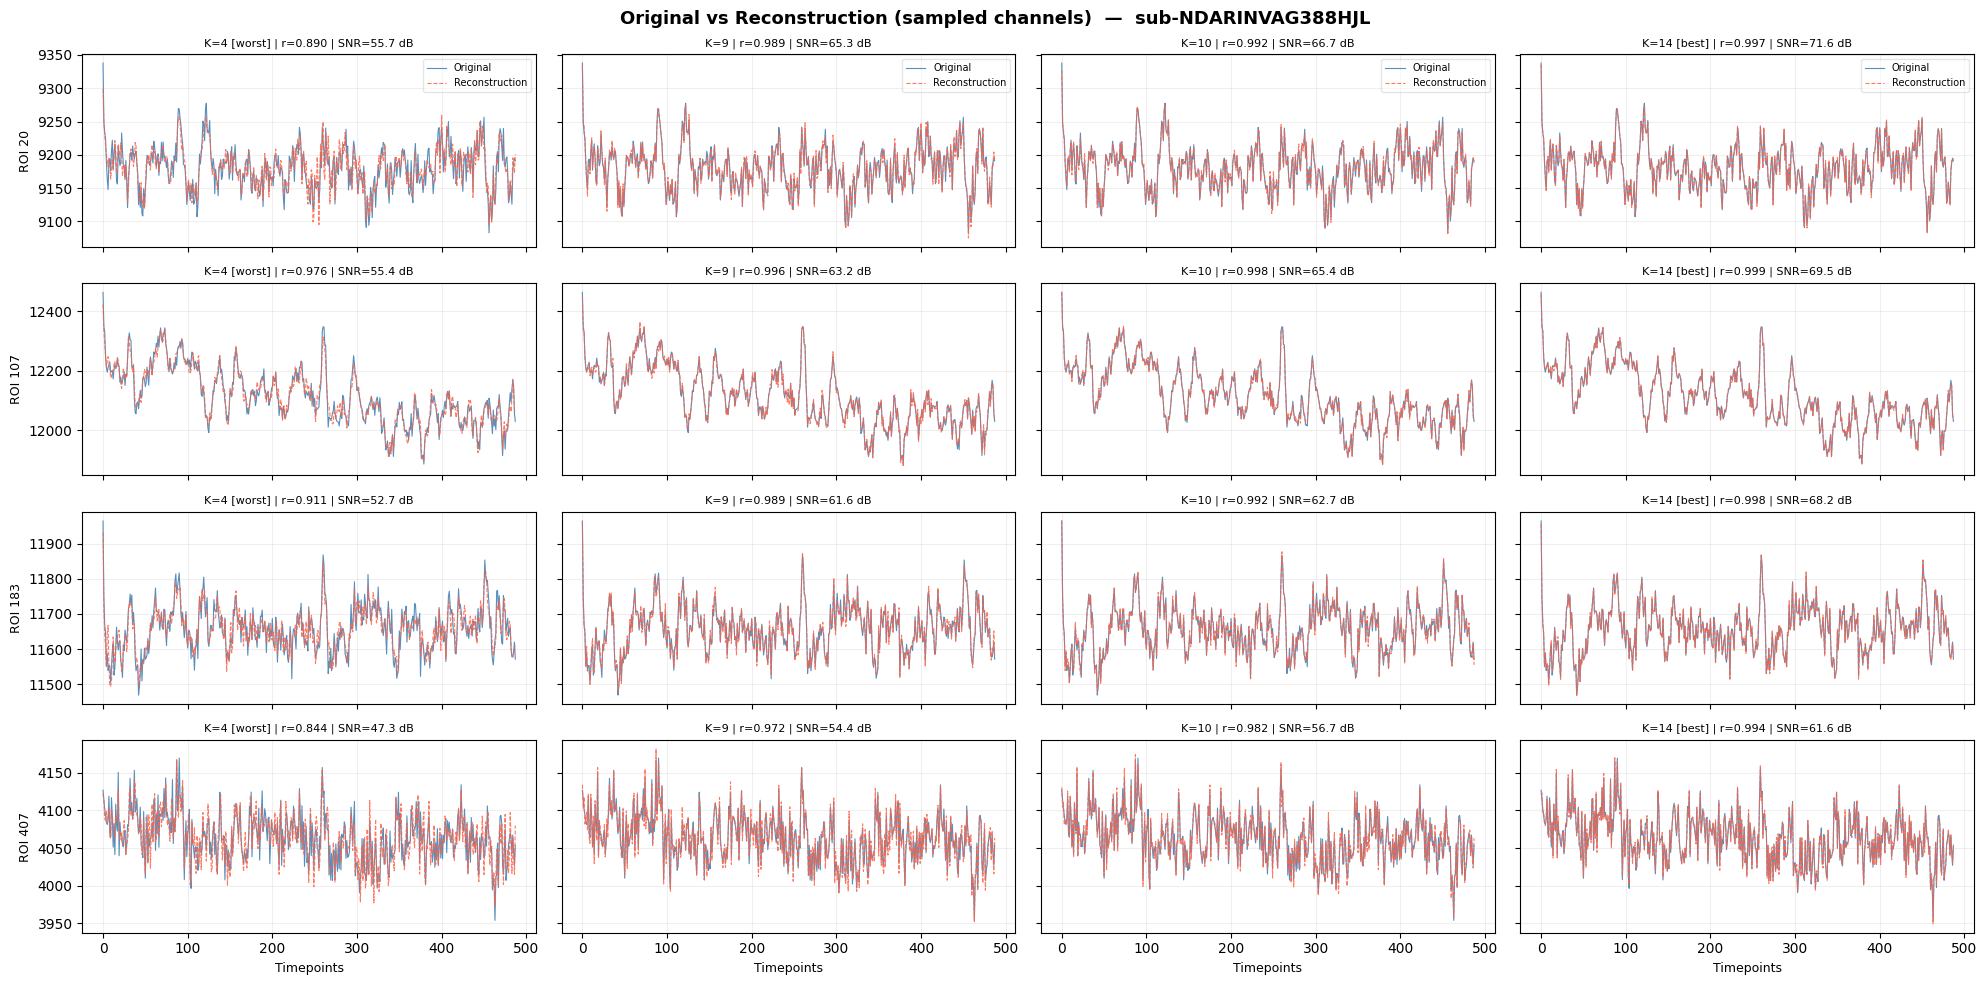

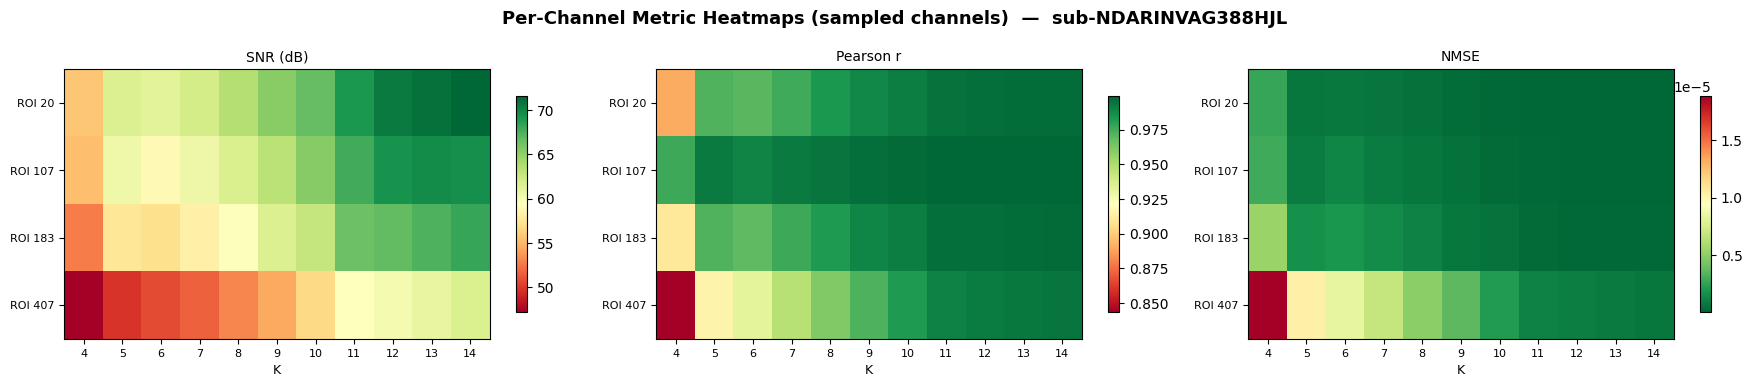


Reconstruction Quality Summary  —  sub-NDARINVAG388HJL
   K |   SNR (dB) |         NMSE |  Pearson r |       R² |     RMSE |      MAE
------------------------------------------------------------------------------
   4 |    52.3943 |   0.00000807 |   0.898231 | 0.801388 |  19.5601 |  15.5856
   5 |    56.4547 |   0.00000354 |   0.956721 | 0.914653 |  12.2534 |   9.7520
   6 |    56.2358 |   0.00000359 |   0.957875 | 0.913150 |  12.5381 |   9.9752
   7 |    57.3596 |   0.00000273 |   0.967643 | 0.933124 |  11.0188 |   8.7837
   8 |    58.6424 |   0.00000200 |   0.976514 | 0.950950 |   9.5158 |   7.5644
   9 |    60.3355 |   0.00000135 |   0.984092 | 0.966845 |   7.8300 |   6.2466
  10 |    62.0969 |   0.00000091 |   0.988930 | 0.977603 |   6.3893 |   5.0798
  11 |    65.1192 |   0.00000045 |   0.994503 | 0.988909 |   4.5107 |   3.5858
  12 |    65.5151 |   0.00000043 |   0.994797 | 0.989458 |   4.3160 |   3.4428
  13 |    66.2165 |   0.00000036 |   0.995692 | 0.991227 |   3.9756 |   3.1

In [420]:
# Visualise reconstruction quality and compare K choices
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

DISPLAY_K_N        = 4  # Total K values shown in signal comparison (always includes best + worst by SNR)
DISPLAY_CHANNELS_N = 4  # Number of randomly sampled channels shown in Figures 2 and 3

for sub_id in sampled_subjects:
  h5_parcellation_group = PARCELLATION_GROUP_TEMPLATE.format(subject_id=sub_id)
  h5_mvmd_group = MVMD_GROUP_TEMPLATE.format(subject_id=sub_id)

  # --- Pass 1: load metrics (needed to determine which K values to display) ---
  with h5py.File(OUTPUT_FILE, 'r') as f:
    roi_indices  = f[h5_mvmd_group].attrs["roi_indices"]
    original     = f[h5_parcellation_group]["cortical_subcortical_parcellation"][roi_indices][:]
    num_channels = original.shape[0]

    decomposition_keys = sorted(
      list_subgroups(f[h5_mvmd_group]),
      key=lambda x: int(x.split("_")[-1])
    )
    k_values = [int(dk.split("_")[-1]) for dk in decomposition_keys]

    mean_metrics = {m: [] for m in ["snr_db", "nmse", "pearson_r", "r_squared", "rmse", "mae"]}
    heat_data    = {m: [] for m in ["snr_db", "pearson_r", "nmse"]}

    for dk in decomposition_keys:
      k  = int(dk.split("_")[-1])
      mg = f[DECOMPOSITION_GROUP_TEMPLATE.format(subject_id=sub_id, k=k)]["metrics"]
      for m in mean_metrics:
        mean_metrics[m].append(mg.attrs[f"mean_{m}"])
      for m in heat_data:
        heat_data[m].append(mg[m][:])

  for m in heat_data:
    heat_data[m] = np.array(heat_data[m])  # (num_K, C)

  # --- Determine which K values to plot (best + worst by SNR, rest random) ---
  snr_vals = np.array(mean_metrics["snr_db"])
  best_k   = k_values[int(np.argmax(snr_vals))]
  worst_k  = k_values[int(np.argmin(snr_vals))]

  remaining  = [k for k in k_values if k not in {best_k, worst_k}]
  n_fill     = max(0, DISPLAY_K_N - 2)
  fill_ks    = sorted(random.sample(remaining, k=min(n_fill, len(remaining))))
  display_ks = sorted({best_k, worst_k} | set(fill_ks))
  print(f"Display K={display_ks}  (best={best_k}, worst={worst_k}, random fill={fill_ks})")

  # --- Pass 2: load reconstructions only for the selected K values ---
  reconstructions    = {}
  ch_metrics_display = {}
  with h5py.File(OUTPUT_FILE, 'r') as f:
    for k in display_ks:
      kg = f[DECOMPOSITION_GROUP_TEMPLATE.format(subject_id=sub_id, k=k)]
      reconstructions[k]    = kg["reconstruction"][:]
      ch_metrics_display[k] = {m: kg["metrics"][m][:] for m in ["pearson_r", "snr_db"]}

  # Sample a fixed set of channel indices used across Figures 2 and 3
  display_ch_indices = sorted(random.sample(range(num_channels), k=min(DISPLAY_CHANNELS_N, num_channels)))
  print(f"Sampled channels: indices {display_ch_indices}  (ROIs: {roi_indices[display_ch_indices]})")

  # ---- Figure 1: Mean metrics vs K (2×3 grid) ----
  metric_configs = [
    ("snr_db",    "Mean SNR (dB)",   True,  "seagreen",     "Higher is better"),
    ("nmse",      "Mean NMSE",       False, "firebrick",    "Lower is better  (0 = perfect)"),
    ("pearson_r", "Mean Pearson r",  True,  "steelblue",    "Higher is better (1 = perfect)"),
    ("r_squared", "Mean R²",         True,  "mediumpurple", "Higher is better (1 = perfect)"),
    ("rmse",      "Mean RMSE",       False, "darkorange",   "Lower is better"),
    ("mae",       "Mean MAE",        False, "saddlebrown",  "Lower is better"),
  ]

  fig, axes = plt.subplots(2, 3, figsize=(16, 8))
  fig.suptitle(f"Reconstruction Quality vs K  —  {sub_id}", fontsize=14, fontweight="bold")

  for ax, (metric_key, label, higher_better, color, subtitle) in zip(axes.flat, metric_configs):
    vals     = np.array(mean_metrics[metric_key])
    best_idx = np.argmax(vals) if higher_better else np.argmin(vals)
    best_k_m = k_values[best_idx]

    ax.plot(k_values, vals, marker="o", color=color, linewidth=2, markersize=5)
    ax.axvline(x=best_k_m, color="gold", linestyle="--", linewidth=1.5, label=f"Best K={best_k_m}")
    ax.scatter([best_k_m], [vals[best_idx]], color="gold", s=80, zorder=5)
    ax.set_xlabel("K (number of modes)", fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(f"{label}\n{subtitle}", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

  plt.tight_layout()
  plt.show()

  # ---- Figure 2: Original vs Reconstruction for sampled channels and selected K values ----
  n_display_ch = len(display_ch_indices)
  fig, axes = plt.subplots(
    n_display_ch, len(display_ks),
    figsize=(5 * len(display_ks), 2.5 * n_display_ch),
    sharex=True, sharey="row"
  )
  if n_display_ch == 1:
    axes = axes[np.newaxis, :]
  if len(display_ks) == 1:
    axes = axes[:, np.newaxis]

  fig.suptitle(f"Original vs Reconstruction (sampled channels)  —  {sub_id}", fontsize=13, fontweight="bold")
  t = np.arange(original.shape[1])

  for j, k in enumerate(display_ks):
    label_suffix = " [best]" if k == best_k else (" [worst]" if k == worst_k else "")
    for row, ch in enumerate(display_ch_indices):
      ax      = axes[row, j]
      r_val   = ch_metrics_display[k]["pearson_r"][ch]
      snr_val = ch_metrics_display[k]["snr_db"][ch]

      ax.plot(t, original[ch],           color="steelblue", linewidth=0.8, alpha=0.9,  label="Original")
      ax.plot(t, reconstructions[k][ch], color="tomato",    linewidth=0.8, alpha=0.85, linestyle="--", label="Reconstruction")
      ax.set_title(f"K={k}{label_suffix} | r={r_val:.3f} | SNR={snr_val:.1f} dB", fontsize=8)

      if j == 0:
        ax.set_ylabel(f"ROI {roi_indices[ch]}", fontsize=9)
      if row == 0:
        ax.legend(loc="upper right", fontsize=7, framealpha=0.5)
      if row == n_display_ch - 1:
        ax.set_xlabel("Timepoints", fontsize=9)
      ax.grid(True, alpha=0.2)

  plt.tight_layout()
  plt.show()

  # ---- Figure 3: Per-channel metric heatmaps for sampled channels across all K values ----
  heat_configs = [
    ("snr_db",    "SNR (dB)",  "RdYlGn"),
    ("pearson_r", "Pearson r", "RdYlGn"),
    ("nmse",      "NMSE",      "RdYlGn_r"),
  ]

  fig, axes = plt.subplots(1, len(heat_configs), figsize=(6 * len(heat_configs), max(2, 0.6 * n_display_ch + 1.5)))
  fig.suptitle(f"Per-Channel Metric Heatmaps (sampled channels)  —  {sub_id}", fontsize=13, fontweight="bold")

  for ax, (metric_key, label, cmap) in zip(axes, heat_configs):
    data = heat_data[metric_key][:, display_ch_indices].T  # (n_display_ch, num_K)
    im   = ax.imshow(data, aspect="auto", cmap=cmap, interpolation="nearest")
    ax.set_xlabel("K", fontsize=9)
    ax.set_xticks(range(len(k_values)))
    ax.set_xticklabels(k_values, fontsize=8)
    ax.set_yticks(range(n_display_ch))
    ax.set_yticklabels([f"ROI {roi_indices[ch]}" for ch in display_ch_indices], fontsize=8)
    ax.set_title(label, fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.8)

  plt.tight_layout()
  plt.show()

  # ---- Summary table ----
  best = {
    "snr_db":    k_values[int(np.argmax(mean_metrics["snr_db"]))],
    "pearson_r": k_values[int(np.argmax(mean_metrics["pearson_r"]))],
    "r_squared": k_values[int(np.argmax(mean_metrics["r_squared"]))],
    "nmse":      k_values[int(np.argmin(mean_metrics["nmse"]))],
    "rmse":      k_values[int(np.argmin(mean_metrics["rmse"]))],
    "mae":       k_values[int(np.argmin(mean_metrics["mae"]))],
  }

  print(f"\nReconstruction Quality Summary  —  {sub_id}")
  header = f"{'K':>4} | {'SNR (dB)':>10} | {'NMSE':>12} | {'Pearson r':>10} | {'R²':>8} | {'RMSE':>8} | {'MAE':>8}"
  print(header)
  print("-" * len(header))

  for i, k in enumerate(k_values):
    flags = []
    if k == best["snr_db"]:    flags.append("SNR")
    if k == best["pearson_r"]: flags.append("r")
    if k == best["r_squared"]: flags.append("R²")
    if k == best["nmse"]:      flags.append("NMSE")
    if k == best["rmse"]:      flags.append("RMSE")
    suffix = f"  <-- best {', '.join(flags)}" if flags else ""

    print(
      f"{k:>4} | {mean_metrics['snr_db'][i]:>10.4f} | "
      f"{mean_metrics['nmse'][i]:>12.8f} | "
      f"{mean_metrics['pearson_r'][i]:>10.6f} | "
      f"{mean_metrics['r_squared'][i]:>8.6f} | "
      f"{mean_metrics['rmse'][i]:>8.4f} | "
      f"{mean_metrics['mae'][i]:>8.4f}{suffix}"
    )

Slow-band mode membership — sub-NDARINVAG388HJL  (* = primary band)
   K          Slow-6          Slow-5          Slow-4          Slow-3          Slow-2          Slow-1         Outside
--------------------------------------------------------------------------------------------------------------------
   4   0 (  0.0%)      0*(  0.0%)      1*( 25.0%)      1*( 25.0%)      0*(  0.0%)      1 ( 25.0%)      1 ( 25.0%)   
   5   0 (  0.0%)      0*(  0.0%)      1*( 20.0%)      1*( 20.0%)      1*( 20.0%)      1 ( 20.0%)      1 ( 20.0%)   
   6   0 (  0.0%)      0*(  0.0%)      1*( 16.7%)      1*( 16.7%)      1*( 16.7%)      2 ( 33.3%)      1 ( 16.7%)   
   7   0 (  0.0%)      0*(  0.0%)      2*( 28.6%)      1*( 14.3%)      1*( 14.3%)      2 ( 28.6%)      1 ( 14.3%)   
   8   0 (  0.0%)      0*(  0.0%)      2*( 25.0%)      1*( 12.5%)      1*( 12.5%)      3 ( 37.5%)      1 ( 12.5%)   
   9   0 (  0.0%)      0*(  0.0%)      2*( 22.2%)      1*( 11.1%)      2*( 22.2%)      3 ( 33.3%)      1 ( 11.1%)

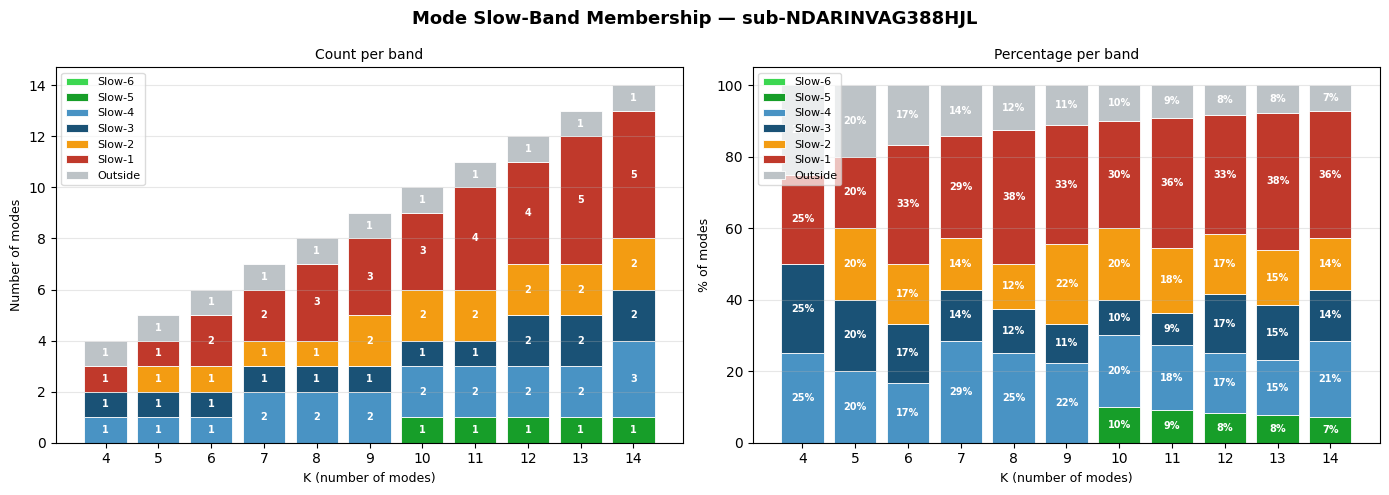

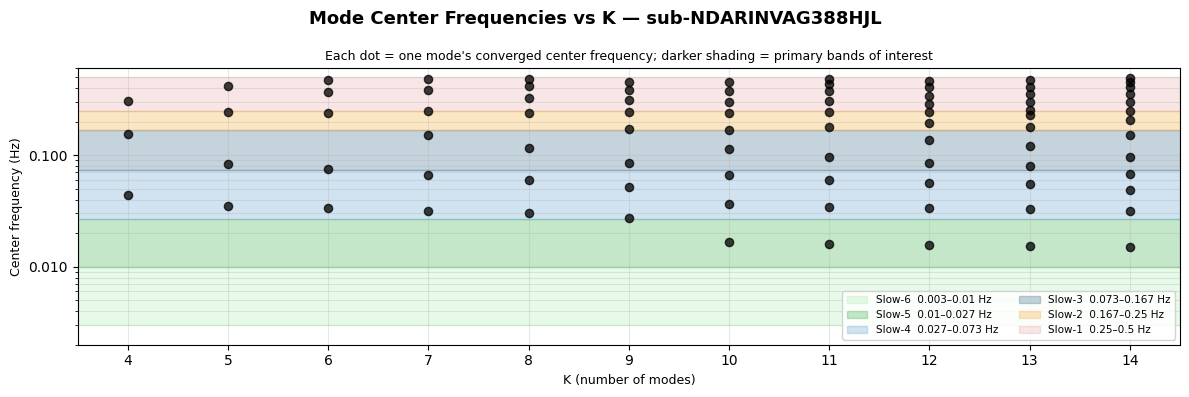

In [421]:
# Slow-band frequency classification of MVMD mode center frequencies
# Band boundaries follow He et al. (2010) / Buzsáki & Draguhn (2004)
# omega is stored as (N_iter, K); omega[-1] gives the K converged center frequencies in Hz

SLOW_BANDS = {  # (low_hz, high_hz): inclusive low, exclusive high
    "Slow-6": (0.003, 0.010),
    "Slow-5": (0.010, 0.027),
    "Slow-4": (0.027, 0.073),
    "Slow-3": (0.073, 0.167),
    "Slow-2": (0.167, 0.250),
    "Slow-1": (0.250, 0.500),
}
PRIMARY_BANDS = {"Slow-5", "Slow-4", "Slow-3", "Slow-2"}

BAND_COLORS = {
    "Slow-6": "#3cd751",
    "Slow-5": "#179e29",
    "Slow-4": "#4993c4",
    "Slow-3": "#1a5276",
    "Slow-2": "#f39c12",
    "Slow-1": "#c0392b",
    "Outside": "#bdc3c7",
}

def classify_omega(freq_hz):
    for band_name, (lo, hi) in SLOW_BANDS.items():
        if lo <= freq_hz < hi:
            return band_name
    return "Outside"

band_order = list(SLOW_BANDS.keys()) + ["Outside"]

for sub_id in sampled_subjects:
  h5_mvmd_group = MVMD_GROUP_TEMPLATE.format(subject_id=sub_id)

  with h5py.File(OUTPUT_FILE, 'r') as f:
    decomposition_keys = sorted(
      list_subgroups(f[h5_mvmd_group]),
      key=lambda x: int(x.split("_")[-1])
    )
    k_values   = [int(dk.split("_")[-1]) for dk in decomposition_keys]
    band_counts = []   # [{band: count}, ...] one dict per K
    mode_freqs  = []   # [array(K,), ...] converged center frequencies per K

    for dk in decomposition_keys:
      k = int(dk.split("_")[-1])
      omega = f[DECOMPOSITION_GROUP_TEMPLATE.format(subject_id=sub_id, k=k)]["omega"][:]
      freqs = omega[-1]  # (N_iter, K) → take final converged row → (K,)
      mode_freqs.append(freqs)

      counts = {b: 0 for b in band_order}
      for freq in freqs:
        counts[classify_omega(float(freq))] += 1
      band_counts.append(counts)

  # ---- Summary table ----
  print(f"Slow-band mode membership — {sub_id}  (* = primary band)")
  col_w = 14
  header = f"{'K':>4}" + "".join(f"  {b:>{col_w}}" for b in band_order)
  print(header)
  print("-" * len(header))

  for i, k in enumerate(k_values):
    row = f"{k:>4}"
    for b in band_order:
      n   = band_counts[i][b]
      pct = 100 * n / k
      marker = "*" if b in PRIMARY_BANDS else " "
      row += f"  {n:>2}{marker}({pct:5.1f}%){' ':>{col_w - 11}}"
    print(row)

  # ---- Figure 1: Stacked bar — count (left) and percentage (right) ----
  x = np.arange(len(k_values))
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
  fig.suptitle(f"Mode Slow-Band Membership — {sub_id}", fontsize=13, fontweight="bold")

  for ax, normalize in [(ax1, False), (ax2, True)]:
    bottom = np.zeros(len(k_values))
    for band in band_order:
      vals = np.array([band_counts[i][band] for i in range(len(k_values))], dtype=float)
      if normalize:
        vals = vals / np.array(k_values) * 100
      bars = ax.bar(x, vals, bottom=bottom, label=band,
                    color=BAND_COLORS[band], edgecolor="white", linewidth=0.6)
      threshold = 1 if not normalize else 4
      for bar, v in zip(bars, vals):
        if v >= threshold:
          ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_y() + bar.get_height() / 2,
            f"{v:.0f}{'%' if normalize else ''}",
            ha="center", va="center", fontsize=7, color="white", fontweight="bold"
          )
      bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(k_values)
    ax.set_xlabel("K (number of modes)", fontsize=9)
    ax.set_ylabel("Number of modes" if not normalize else "% of modes", fontsize=9)
    ax.set_title("Count per band" if not normalize else "Percentage per band", fontsize=10)
    ax.legend(loc="upper left", fontsize=8, framealpha=0.7)
    ax.grid(axis="y", alpha=0.3)

  plt.tight_layout()
  plt.show()

  # ---- Figure 2: Scatter of converged center frequencies on a log-frequency axis ----
  fig, ax = plt.subplots(figsize=(12, 4))
  fig.suptitle(f"Mode Center Frequencies vs K — {sub_id}", fontsize=13, fontweight="bold")

  for band_name, (lo, hi) in SLOW_BANDS.items():
    alpha  = 0.25 if band_name in PRIMARY_BANDS else 0.12
    ax.axhspan(lo, hi, alpha=alpha, color=BAND_COLORS[band_name],
               label=f"{band_name}  {lo}–{hi} Hz")

  for k, freqs in zip(k_values, mode_freqs):
    ax.scatter([k] * len(freqs), freqs, s=35, color="black", alpha=0.75, zorder=3)

  ax.set_xlabel("K (number of modes)", fontsize=9)
  ax.set_ylabel("Center frequency (Hz)", fontsize=9)
  ax.set_yscale("log")
  ax.set_ylim(0.002, 0.6)
  ax.set_xticks(k_values)
  ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:.3f}"))
  ax.legend(loc="lower right", fontsize=7.5, framealpha=0.85, ncol=2)
  ax.grid(True, alpha=0.3, which="both")
  ax.set_title("Each dot = one mode's converged center frequency; darker shading = primary bands of interest", fontsize=9)

  plt.tight_layout()
  plt.show()

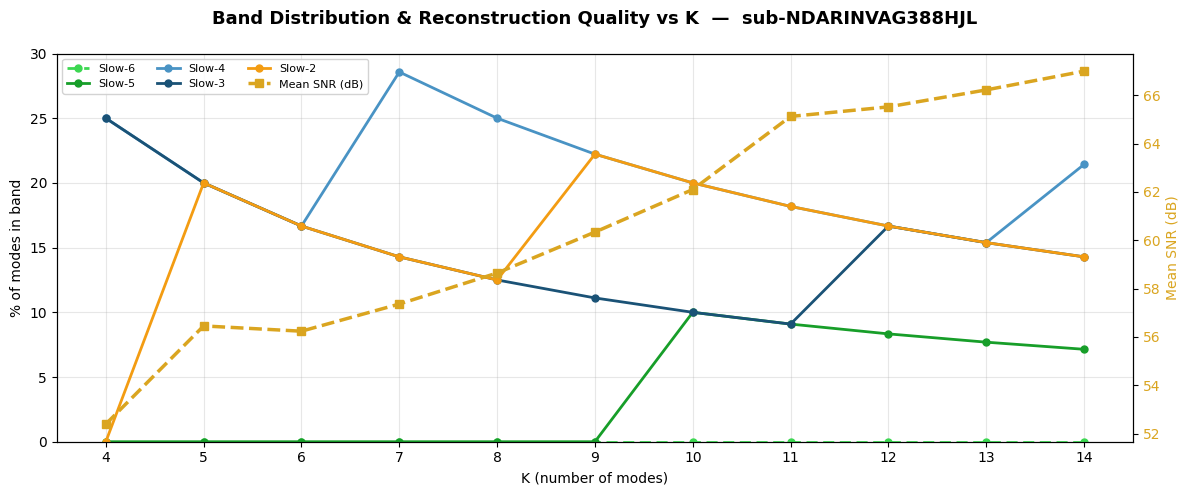

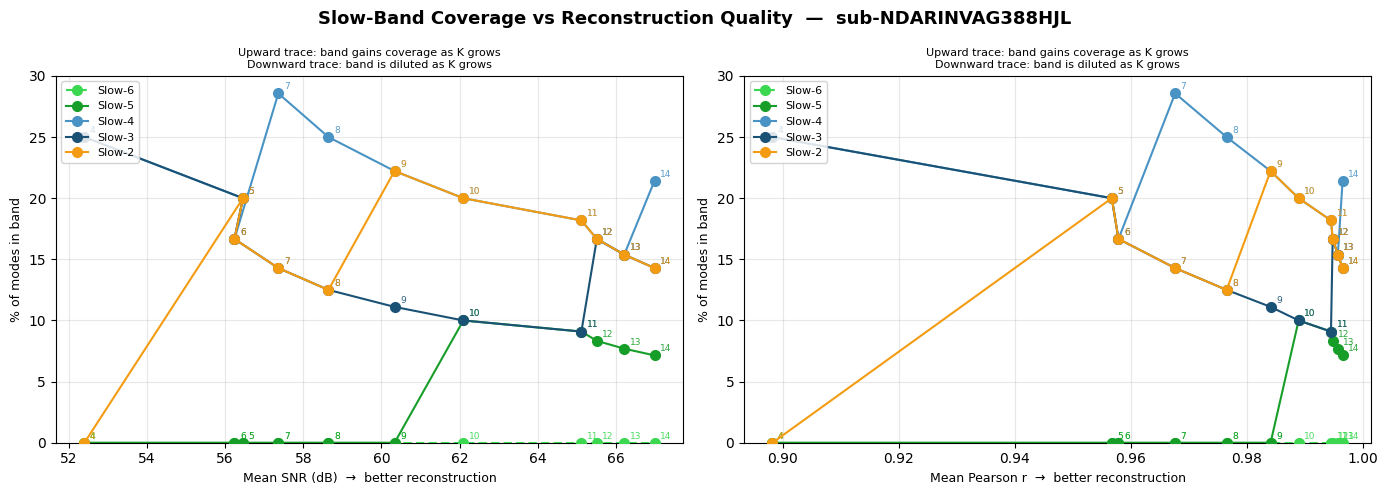

In [422]:
# Slow-band coverage vs reconstruction quality tradeoff
# Depends on: SLOW_BANDS, PRIMARY_BANDS, BAND_COLORS, classify_omega, band_order (defined in previous cell)

TRADEOFF_BANDS = ["Slow-6", "Slow-5", "Slow-4", "Slow-3", "Slow-2"]  # bands to trace (Slow-1 / Outside omitted)

for sub_id in sampled_subjects:
  h5_mvmd_group = MVMD_GROUP_TEMPLATE.format(subject_id=sub_id)

  with h5py.File(OUTPUT_FILE, 'r') as f:
    decomposition_keys = sorted(
      list_subgroups(f[h5_mvmd_group]),
      key=lambda x: int(x.split("_")[-1])
    )
    k_values = [int(dk.split("_")[-1]) for dk in decomposition_keys]

    band_pcts    = {b: [] for b in TRADEOFF_BANDS}
    mean_snr_arr = []
    mean_r_arr   = []

    for dk in decomposition_keys:
      k      = int(dk.split("_")[-1])
      k_path = DECOMPOSITION_GROUP_TEMPLATE.format(subject_id=sub_id, k=k)

      omega = f[k_path]["omega"][:]
      freqs = omega[-1]  # final converged row
      counts = {b: 0 for b in band_order}
      for freq in freqs:
        counts[classify_omega(float(freq))] += 1

      for b in TRADEOFF_BANDS:
        band_pcts[b].append(100 * counts[b] / k)

      mean_snr_arr.append(f[k_path]["metrics"].attrs["mean_snr_db"])
      mean_r_arr.append(f[k_path]["metrics"].attrs["mean_pearson_r"])

  mean_snr_arr = np.array(mean_snr_arr)
  mean_r_arr   = np.array(mean_r_arr)

  # ---- Figure A: dual y-axis — band % and SNR co-evolving over K ----
  fig, ax_band = plt.subplots(figsize=(12, 5))
  ax_snr = ax_band.twinx()
  fig.suptitle(f"Band Distribution & Reconstruction Quality vs K  —  {sub_id}", fontsize=13, fontweight="bold")

  for band in TRADEOFF_BANDS:
    pcts = np.array(band_pcts[band])
    ls   = "-" if band in PRIMARY_BANDS else (0, (4, 2))  # solid for primary, looser dash for Slow-6
    ax_band.plot(k_values, pcts, marker="o", color=BAND_COLORS[band],
                 linewidth=2, markersize=5, linestyle=ls, label=band, zorder=3)

  ax_snr.plot(k_values, mean_snr_arr, marker="s", color="goldenrod",
              linewidth=2.5, markersize=6, linestyle="--", label="Mean SNR (dB)", zorder=2)

  ax_band.set_xlabel("K (number of modes)", fontsize=10)
  ax_band.set_ylabel("% of modes in band", fontsize=10)
  ax_snr.set_ylabel("Mean SNR (dB)", fontsize=10, color="goldenrod")
  ax_snr.tick_params(axis="y", labelcolor="goldenrod")
  ax_band.set_xticks(k_values)
  ax_band.set_ylim(bottom=0)
  ax_band.grid(True, alpha=0.3)

  lines_b, labels_b = ax_band.get_legend_handles_labels()
  lines_s, labels_s = ax_snr.get_legend_handles_labels()
  ax_band.legend(lines_b + lines_s, labels_b + labels_s,
                 loc="upper left", fontsize=8, framealpha=0.85, ncol=3)

  plt.tight_layout()
  plt.show()

  # ---- Figure B: tradeoff scatter — SNR (x) vs band % (y), one trace per band ----
  # Each point = one K value. Moving right = better reconstruction (higher K).
  # An upward trace means the band gains proportional coverage as K grows.
  # A downward trace means that band is diluted as K grows.

  fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
  fig.suptitle(f"Slow-Band Coverage vs Reconstruction Quality  —  {sub_id}", fontsize=13, fontweight="bold")

  for ax, (x_vals, x_label) in zip(axes, [
    (mean_snr_arr, "Mean SNR (dB)"),
    (mean_r_arr,   "Mean Pearson r"),
  ]):
    for band in TRADEOFF_BANDS:
      pcts = np.array(band_pcts[band])
      ls   = "-" if band in PRIMARY_BANDS else (0, (4, 2))
      ax.plot(x_vals, pcts, marker="o", color=BAND_COLORS[band],
              linewidth=1.5, markersize=7, linestyle=ls, label=band, zorder=3)

      # Label each point with its K
      for k, xv, yv in zip(k_values, x_vals, pcts):
        ax.annotate(
          str(k), xy=(xv, yv),
          xytext=(4, 3), textcoords="offset points",
          fontsize=6.5, color=BAND_COLORS[band], alpha=0.9
        )

    ax.set_xlabel(f"{x_label}  →  better reconstruction", fontsize=9)
    ax.set_ylabel("% of modes in band", fontsize=9)
    ax.set_ylim(bottom=0)
    ax.legend(loc="upper left", fontsize=8, framealpha=0.85)
    ax.grid(True, alpha=0.3)
    ax.set_title(
      "Upward trace: band gains coverage as K grows\n"
      "Downward trace: band is diluted as K grows",
      fontsize=8
    )

  plt.tight_layout()
  plt.show()